DIVAR REAL ESTATE PRICE PREDICTION
📊 Dataset shape: (10622, 61)
📋 Columns count: 61

PREPROCESSING DATA
Initial records: 10,622
After price extraction: 7,591 records (removed 3,031)

Processing numeric features...
  Processing land_size...
  Processing building_size...
  Processing floor...
  Processing rooms_count...
  Processing total_floors_count...
  Processing unit_per_floor...
  Processing construction_year...

Processing binary features...

Feature engineering...

Removing outliers...
Final records after all processing: 7,528

PREPARING DATA FOR MODELING
Using 25 numeric features and 4 categorical features
Categorical features: ['city_slug', 'neighborhood_slug', 'user_type', 'cat2_slug']
After one-hot encoding: 1091 features
Train: 5,269, Val: 1,129, Test: 1,130
Number of features: 1091

TRAINING MODELS

🚀 Training Random Forest...
  ✅ Val R²: 0.9921
  ✅ Test R²: 0.9879
  ✅ Test MAE: 692,077,222

🚀 Training Gradient Boosting...
  ✅ Val R²: 0.9873
  ✅ Test R²: 0.9829
  ✅ Test MAE

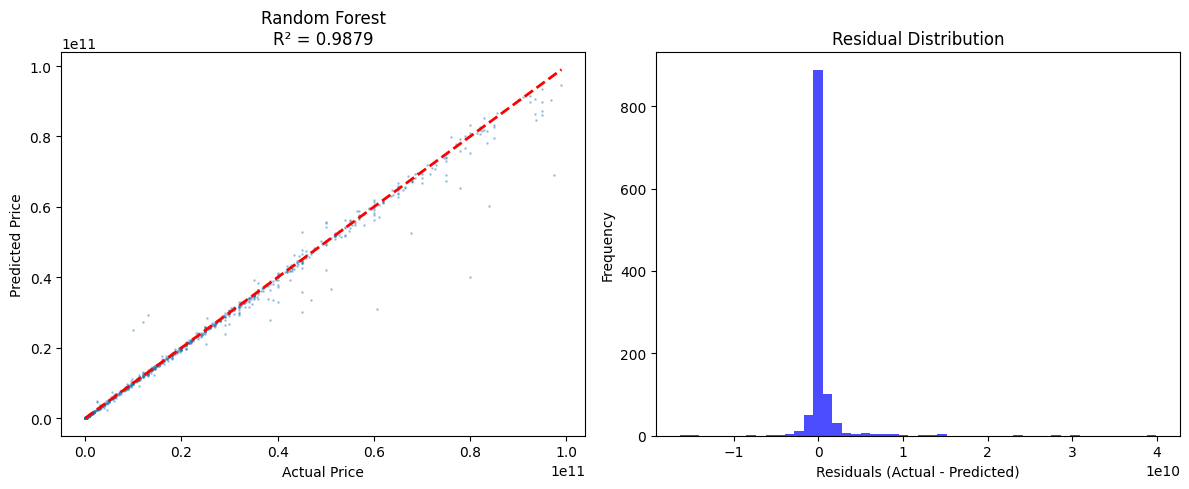


✅ PROGRAM COMPLETED


In [ ]:
# -*- coding: utf-8 -*-
"""
Divar Real Estate Price Prediction — Optimized Version with Error Handling
"""

# =============================================
# بخش اول: نصب و وارد کردن کتابخانه‌ها
# =============================================
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import joblib
import re

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.feature_extraction.text import TfidfVectorizer

import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')

# =============================================
# بخش دوم: بارگذاری داده‌ها
# =============================================
print("="*60)
print("DIVAR REAL ESTATE PRICE PREDICTION")
print("="*60)

# try:
#     df = pd.read_csv("Divar.csv", encoding="utf-8", on_bad_lines="skip", low_memory=False)
#     print("✅ Dataset loaded successfully with UTF-8 encoding")
# except UnicodeDecodeError:
#     try:
#         df = pd.read_csv("Divar.csv", encoding="latin1", on_bad_lines="skip", low_memory=False)
#         print("✅ Dataset loaded successfully with Latin-1 encoding")
#     except:
#         df = pd.read_csv("Divar.csv", encoding="cp1256", on_bad_lines="skip", low_memory=False)
#         print("✅ Dataset loaded successfully with CP1256 encoding")

df = pd.read_csv("../../../data/Divar.csv")
print(f"📊 Dataset shape: {df.shape}")
print(f"📋 Columns count: {len(df.columns)}")

# =============================================
# بخش سوم: توابع کمکی
# =============================================
def fa_to_en_digits(text):
    """تبدیل اعداد فارسی و عربی به انگلیسی"""
    if pd.isna(text):
        return "0"
    text = str(text)
    # دیکشنری تبدیل
    mapping = {
        '۰': '0', '۱': '1', '۲': '2', '۳': '3', '۴': '4',
        '۵': '5', '۶': '6', '۷': '7', '۸': '8', '۹': '9',
        '٠': '0', '١': '1', '٢': '2', '٣': '3', '٤': '4',
        '٥': '5', '٦': '6', '٧': '7', '٨': '8', '٩': '9'
    }
    for fa, en in mapping.items():
        text = text.replace(fa, en)
    return text

def safe_to_numeric(series, default=0):
    """تبدیل ایمن به عدد با مدیریت خطا"""
    try:
        # ابتدا تبدیل به رشته و حذف کاراکترهای غیرعددی
        series = series.astype(str).str.replace(r'[^\d]', '', regex=True)
        series = series.replace('', '0')
        result = pd.to_numeric(series, errors='coerce')
        # اگر همه NaN بودند، از مقدار پیش‌فرض استفاده کن
        if result.isna().all():
            return pd.Series([default] * len(series), index=series.index)
        # پر کردن NaN با میانه
        median_val = result.median()
        if pd.isna(median_val):
            median_val = default
        return result.fillna(median_val)
    except Exception as e:
        print(f"  ⚠️ Error in safe_to_numeric: {e}, using default")
        return pd.Series([default] * len(series), index=series.index)

# =============================================
# بخش چهارم: پیش‌پردازش داده‌ها
# =============================================
print("\n" + "="*60)
print("PREPROCESSING DATA")
print("="*60)

df_clean = df.copy()
initial_count = len(df_clean)
print(f"Initial records: {initial_count:,}")

# 1. ایجاد متغیر هدف (قیمت)
def extract_price(row):
    """استخراج قیمت از ستون‌های مختلف"""
    # اولویت 1: price_value
    if 'price_value' in row.index and pd.notna(row.get('price_value')):
        try:
            val = str(row['price_value'])
            # حذف کاراکترهای غیرعددی
            val = re.sub(r'[^\d]', '', val)
            if val and val != '0':
                return float(val)
        except:
            pass

    # اولویت 2: transformable_price
    if 'transformable_price' in row.index and pd.notna(row.get('transformable_price')):
        try:
            val = float(row['transformable_price'])
            if val > 0:
                return val
        except:
            pass

    # اولویت 3: rent_value (برای اجاره)
    if 'rent_value' in row.index and pd.notna(row.get('rent_value')):
        try:
            val = str(row['rent_value'])
            val = re.sub(r'[^\d]', '', val)
            if val and val != '0':
                return float(val) * 12  # تبدیل اجاره ماهانه به سالانه
        except:
            pass

    return np.nan

# اعمال استخراج قیمت
df_clean['target_price'] = df_clean.apply(extract_price, axis=1)
df_clean['target_price'] = pd.to_numeric(df_clean['target_price'], errors='coerce')

# حذف رکوردهای بدون قیمت یا قیمت نامعتبر
df_clean = df_clean[df_clean['target_price'].notna()]
df_clean = df_clean[df_clean['target_price'] > 1000000]  # حداقل 1 میلیون تومان
df_clean = df_clean[df_clean['target_price'] < 1e11]     # حداکثر 100 میلیارد تومان

print(f"After price extraction: {len(df_clean):,} records (removed {initial_count - len(df_clean):,})")

if len(df_clean) == 0:
    print("\n❌ No valid price data found!")
    print("Checking available price columns...")
    price_cols = ['price_value', 'transformable_price', 'rent_value', 'transformable_rent']
    for col in price_cols:
        if col in df.columns:
            non_null = df[col].notna().sum()
            print(f"  {col}: {non_null:,} non-null values")
    raise SystemExit("No valid data for modeling")

# 2. پردازش ویژگی‌های عددی
print("\nProcessing numeric features...")
numeric_features = [
    'land_size', 'building_size', 'floor', 'rooms_count',
    'total_floors_count', 'unit_per_floor', 'construction_year'
]

for col in numeric_features:
    if col in df_clean.columns:
        print(f"  Processing {col}...")
        # تبدیل اعداد فارسی به انگلیسی و سپس به عدد
        df_clean[col] = df_clean[col].apply(lambda x: fa_to_en_digits(x) if pd.notna(x) else "0")
        df_clean[col] = safe_to_numeric(df_clean[col], default=0)
    else:
        print(f"  ⚠️ {col} not found, creating with default 0")
        df_clean[col] = 0

# 3. پردازش ویژگی‌های باینری
print("\nProcessing binary features...")
binary_features = [
    'has_balcony', 'has_elevator', 'has_warehouse', 'has_parking',
    'is_rebuilt', 'has_water', 'has_gas', 'has_heating_system',
    'has_cooling_system', 'has_pool', 'has_jacuzzi', 'has_sauna'
]

for col in binary_features:
    if col in df_clean.columns:
        try:
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce').fillna(0).astype(int)
        except:
            df_clean[col] = 0
    else:
        df_clean[col] = 0

# 4. مهندسی ویژگی‌ها
print("\nFeature engineering...")
df_clean['building_to_land_ratio'] = df_clean['building_size'] / (df_clean['land_size'] + 1)
df_clean['building_age'] = np.maximum(0, 1400 - df_clean['construction_year'].replace(0, 1400))
df_clean['total_amenities'] = df_clean[binary_features].sum(axis=1)
df_clean['price_per_meter'] = df_clean['target_price'] / (df_clean['building_size'] + 1)
df_clean['is_top_floor'] = ((df_clean['floor'] == df_clean['total_floors_count']) & (df_clean['total_floors_count'] > 0)).astype(int)
df_clean['is_first_floor'] = (df_clean['floor'] == 1).astype(int)

# 5. حذف موارد پرت (با دقت کمتر)
print("\nRemoving outliers...")
for col in ['target_price', 'building_size', 'land_size']:
    if col in df_clean.columns:
        Q1 = df_clean[col].quantile(0.01)
        Q3 = df_clean[col].quantile(0.99)
        IQR = Q3 - Q1
        lower_bound = Q1 - 2 * IQR
        upper_bound = Q3 + 2 * IQR
        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

print(f"Final records after all processing: {len(df_clean):,}")

if len(df_clean) < 100:
    print("⚠️ Very few records remaining! Adjusting filters...")
    # کاهش محدودیت‌ها
    df_clean = df_clean[df_clean['target_price'] > 10000]
    df_clean = df_clean[df_clean['target_price'] < 1e12]
    print(f"After adjusting price limits: {len(df_clean):,}")

# =============================================
# بخش پنجم: آماده‌سازی برای مدل‌سازی
# =============================================
print("\n" + "="*60)
print("PREPARING DATA FOR MODELING")
print("="*60)

# انتخاب ویژگی‌های عددی
feature_cols = numeric_features + binary_features + [
    'building_to_land_ratio', 'building_age', 'total_amenities',
    'price_per_meter', 'is_top_floor', 'is_first_floor'
]

# انتخاب ویژگی‌های categorical
categorical_cols = []
for col in ['city_slug', 'neighborhood_slug', 'user_type', 'cat2_slug']:
    if col in df_clean.columns:
        # فقط ستون‌هایی که تنوع دارند و تعداد مقادیر منحصربفرد معقولی دارند
        if df_clean[col].nunique() > 1 and df_clean[col].nunique() < 1000:
            categorical_cols.append(col)
            # پر کردن مقادیر خالی
            df_clean[col] = df_clean[col].fillna('unknown')
            # تبدیل به رشته
            df_clean[col] = df_clean[col].astype(str)

print(f"Using {len(feature_cols)} numeric features and {len(categorical_cols)} categorical features")
print(f"Categorical features: {categorical_cols}")

# آماده‌سازی داده‌ها - شامل همه ستون‌ها
X = df_clean[feature_cols + categorical_cols].copy()
X = X.fillna(0)

# تبدیل categorical با get_dummies
if categorical_cols:
    X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
    print(f"After one-hot encoding: {X.shape[1]} features")

y = df_clean['target_price'].copy()

# اعمال لاگ‌ترانسفورم روی هدف
y_log = np.log1p(y)

# تقسیم داده‌ها
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_log, test_size=0.3, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print(f"Train: {len(X_train):,}, Val: {len(X_val):,}, Test: {len(X_test):,}")
print(f"Number of features: {X.shape[1]}")

# =============================================
# بخش ششم: آموزش مدل‌ها
# =============================================
print("\n" + "="*60)
print("TRAINING MODELS")
print("="*60)

models_dict = {
    'Random Forest': RandomForestRegressor(
        n_estimators=100, max_depth=12, min_samples_split=5,
        random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=100, learning_rate=0.05, max_depth=5,
        random_state=42
    ),
    'XGBoost': xgb.XGBRegressor(
        n_estimators=100, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, device="cuda"

    ),
    'LightGBM': lgb.LGBMRegressor(
        n_estimators=100, learning_rate=0.05, num_leaves=31,
        feature_fraction=0.8, bagging_fraction=0.8,
        bagging_freq=5, random_state=42, n_jobs=-1,device='gpu'
    ),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.001, max_iter=5000)
}

results = []
predictions = {}

for name, model in models_dict.items():
    print(f"\n🚀 Training {name}...")
    try:
        model.fit(X_train, y_train)

        # پیش‌بینی و تبدیل به قیمت واقعی
        y_train_pred = np.expm1(model.predict(X_train))
        y_val_pred = np.expm1(model.predict(X_val))
        y_test_pred = np.expm1(model.predict(X_test))

        y_train_actual = np.expm1(y_train)
        y_val_actual = np.expm1(y_val)
        y_test_actual = np.expm1(y_test)

        metrics = {
            'model': name,
            'train_r2': r2_score(y_train_actual, y_train_pred),
            'val_r2': r2_score(y_val_actual, y_val_pred),
            'test_r2': r2_score(y_test_actual, y_test_pred),
            'test_mae': mean_absolute_error(y_test_actual, y_test_pred),
            'test_mse': mean_squared_error(y_test_actual, y_test_pred)
        }
        results.append(metrics)
        predictions[name] = (y_test_actual, y_test_pred)

        print(f"  ✅ Val R²: {metrics['val_r2']:.4f}")
        print(f"  ✅ Test R²: {metrics['test_r2']:.4f}")
        print(f"  ✅ Test MAE: {metrics['test_mae']:,.0f}")
    except Exception as e:
        print(f"  ❌ Error: {str(e)[:100]}")

# =============================================
# بخش هفتم: نتایج نهایی
# =============================================
print("\n" + "="*60)
print("FINAL RESULTS")
print("="*60)

if results:
    results_df = pd.DataFrame(results).sort_values('test_r2', ascending=False)
    print("\n🏆 Model Performance Comparison:")
    print(results_df[['model', 'test_r2', 'test_mae']].to_string(index=False))

    best_model_name = results_df.iloc[0]['model']
    best_model = models_dict[best_model_name]

    print(f"\n🎯 Best Model: {best_model_name}")
    print(f"   Test R²: {results_df.iloc[0]['test_r2']:.4f}")
    print(f"   Test MAE: {results_df.iloc[0]['test_mae']:,.0f}")

    # ذخیره مدل
    joblib.dump(best_model, 'best_divar_model.pkl')
    print(f"\n💾 Best model saved to 'best_divar_model.pkl'")

    # مصورسازی
    if best_model_name in predictions:
        y_actual, y_pred = predictions[best_model_name]

        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        plt.scatter(y_actual, y_pred, alpha=0.3, s=1)
        plt.plot([y_actual.min(), y_actual.max()],
                 [y_actual.min(), y_actual.max()], 'r--', linewidth=2)
        plt.xlabel('Actual Price')
        plt.ylabel('Predicted Price')
        plt.title(f'{best_model_name}\nR² = {results_df.iloc[0]["test_r2"]:.4f}')

        plt.subplot(1, 2, 2)
        residuals = y_actual - y_pred
        plt.hist(residuals, bins=50, alpha=0.7, color='blue')
        plt.xlabel('Residuals (Actual - Predicted)')
        plt.ylabel('Frequency')
        plt.title('Residual Distribution')

        plt.tight_layout()
        plt.savefig('model_results.png', dpi=300, bbox_inches='tight')
        plt.show()
else:
    print("❌ No models trained successfully!")

print("\n" + "="*60)
print("✅ PROGRAM COMPLETED")
print("="*60)